# Per vedere come sono venuti!

In [1]:
import h5py
import numpy as np

# Percorso del file generato da EasySpin
file_path = "../data/10k/odmr_easyspin_raw_10000.mat"

# Lettura tramite h5py (standard per MAT-file v7.3)
with h5py.File(file_path, "r") as f:
    # MATLAB salva i dataset trasposti (colonna-prioritaria vs riga-prioritaria)
    # Applichiamo .T per ripristinare la forma corretta: [N_spettri, N_punti]
    spectra_data = np.array(f["spectra_data"]).T
    labels_B = np.array(f["labels_B"]).squeeze()
    labels_D = np.array(f["labels_D"]).squeeze()
    labels_lw = np.array(f["labels_lw"]).squeeze()
    labels_c = np.array(f["labels_c"]).squeeze()
    labels_s = np.array(f["labels_s"]).squeeze()
    mw_freqs = np.array(f["mw_freqs"]).squeeze()

# Verifica delle dimensioni e dei range fisici
print("--- Controllo Dimensioni ---")
print(f"Spettri grezzi:    {spectra_data.shape} (atteso: [10000, 167])")
print(f"Labels B (mT):     {labels_B.shape}     (atteso: [10000])")
print(f"Labels D (MHz):    {labels_D.shape}     (atteso: [10000])")
print(f"Labels lw (MHz):   {labels_lw.shape}    (atteso: [10000])")
print(f"Asse Frequenze:    {mw_freqs.shape}     (atteso: [167])")

print("\n--- Controllo Valori ---")
print(
    f"Frequenze MW: da {mw_freqs.min():.3f} a {mw_freqs.max():.3f} GHz (o MHz a seconda di EasySpin)"
)
print(f"B field range: da {labels_B.min():.3f} a {labels_B.max():.3f} mT")
print(f"D range:       da {labels_D.min():.1f} a {labels_D.max():.1f} MHz")

--- Controllo Dimensioni ---
Spettri grezzi:    (10000, 167) (atteso: [10000, 167])
Labels B (mT):     (10000,)     (atteso: [10000])
Labels D (MHz):    (10000,)     (atteso: [10000])
Labels lw (MHz):   (10000,)    (atteso: [10000])
Asse Frequenze:    (167,)     (atteso: [167])

--- Controllo Valori ---
Frequenze MW: da 2.750 a 2.950 GHz (o MHz a seconda di EasySpin)
B field range: da 0.002 a 0.237 mT
D range:       da 2842.0 a 2878.0 MHz


### 1 milione di fotoni


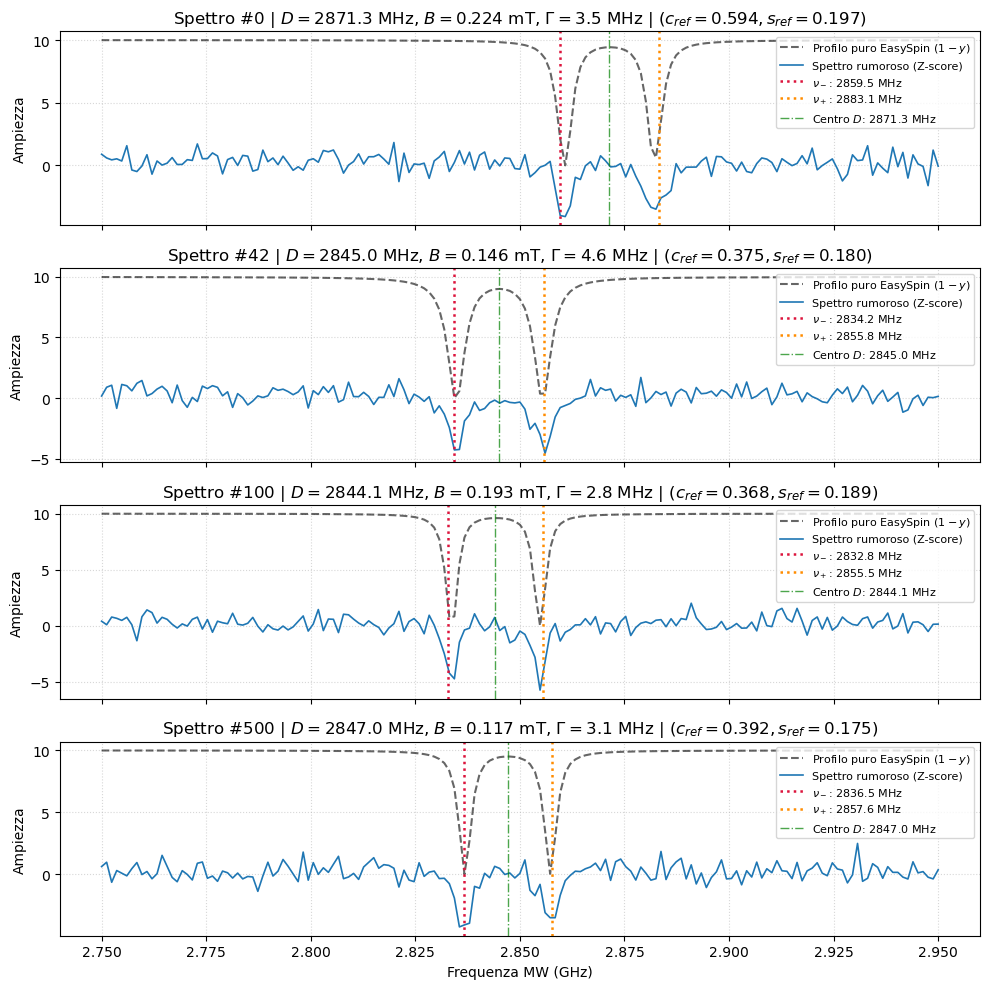

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Selezioniamo 4 indici di spettri dal dataset
sample_indices = [0, 42, 100, 500]

# Griglia di frequenze fisiche in GHz e MHz
f_ghz = mw_freqs  # array da 2.75 a 2.95 GHz (167 punti)
f_mhz = (
    f_ghz * 1e3 if f_ghz.max() < 10.0 else f_ghz
)  # assicuriamoci sia in MHz per i calcoli

fig, axes = plt.subplots(
    len(sample_indices), 1, figsize=(10, 10), sharex=True
)

for ax_idx, idx in enumerate(sample_indices):
    ax = axes[ax_idx]

    # Spettro puro di assorbimento calcolato da EasySpin (normalizzato al picco 1)
    y_raw = spectra_data[idx]

    # Parametri fisici estratti da MATLAB
    D_val = labels_D[idx]  # in MHz
    B_val = labels_B[idx]  # in mT
    lw_val = labels_lw[idx]  # in MHz
    c_ref = labels_c[idx]  # centro normalizzato campionato su 120 MHz
    s_ref = labels_s[idx]  # splitting normalizzato campionato su 120 MHz

    # Frequenze teoriche monoassiali del laboratorio:
    delta_half = np.sqrt(10.0**2 + (28.0 * B_val) ** 2)
    nu_minus = D_val - delta_half
    nu_plus = D_val + delta_half

    # Simulazione rapida del segnale sperimentale (contrasto 10% + e 1 milione di fotoni)
    # nella versione definitiva sono valori da estrarre casualmente come fa Yao
    contrast = 0.10
    signal_ideal = 1.0 - contrast * y_raw
    n_photons = 1e6
    expected_photons = n_photons * (signal_ideal / np.sum(signal_ideal))
    noisy_photons = np.random.poisson(expected_photons)
    noisy_norm = (noisy_photons - np.mean(noisy_photons)) / np.std(
        noisy_photons
    )

    # Plot 1: Spettro ideale EasySpin invertito (profilo liscio di PL)
    ax.plot(
        f_ghz,
        10*(1.0 - y_raw),
        color="black",
        lw=1.5,
        alpha=0.6,
        linestyle="--",
        label="Profilo puro EasySpin ($1 - y$)",
    )

    # Plot 2: Spettro Z-score rumoroso
    ax.plot(
        f_ghz,
        noisy_norm,
        color="#1f77b4",
        lw=1.2,
        label="Spettro rumoroso (Z-score)",
    )

    # Riferimenti fisici dei picchi monoassiali
    ax.axvline(
        nu_minus / 1e3,
        color="crimson",
        linestyle=":",
        lw=1.8,
        label=f"$\\nu_-$: {nu_minus:.1f} MHz",
    )
    ax.axvline(
        nu_plus / 1e3,
        color="darkorange",
        linestyle=":",
        lw=1.8,
        label=f"$\\nu_+$: {nu_plus:.1f} MHz",
    )
    ax.axvline(
        D_val / 1e3,
        color="green",
        linestyle="-.",
        lw=1.0,
        alpha=0.7,
        label=f"Centro $D$: {D_val:.1f} MHz",
    )

    ax.set_ylabel("Ampiezza")
    ax.set_title(
        f"Spettro #{idx} | $D={D_val:.1f}$ MHz, $B={B_val:.3f}$ mT, $\\Gamma={lw_val:.1f}$ MHz | $(c_{{ref}}={c_ref:.3f}, s_{{ref}}={s_ref:.3f})$"
    )
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Frequenza MW (GHz)")
plt.tight_layout()
plt.show()

### 10 miliardi di fotoni

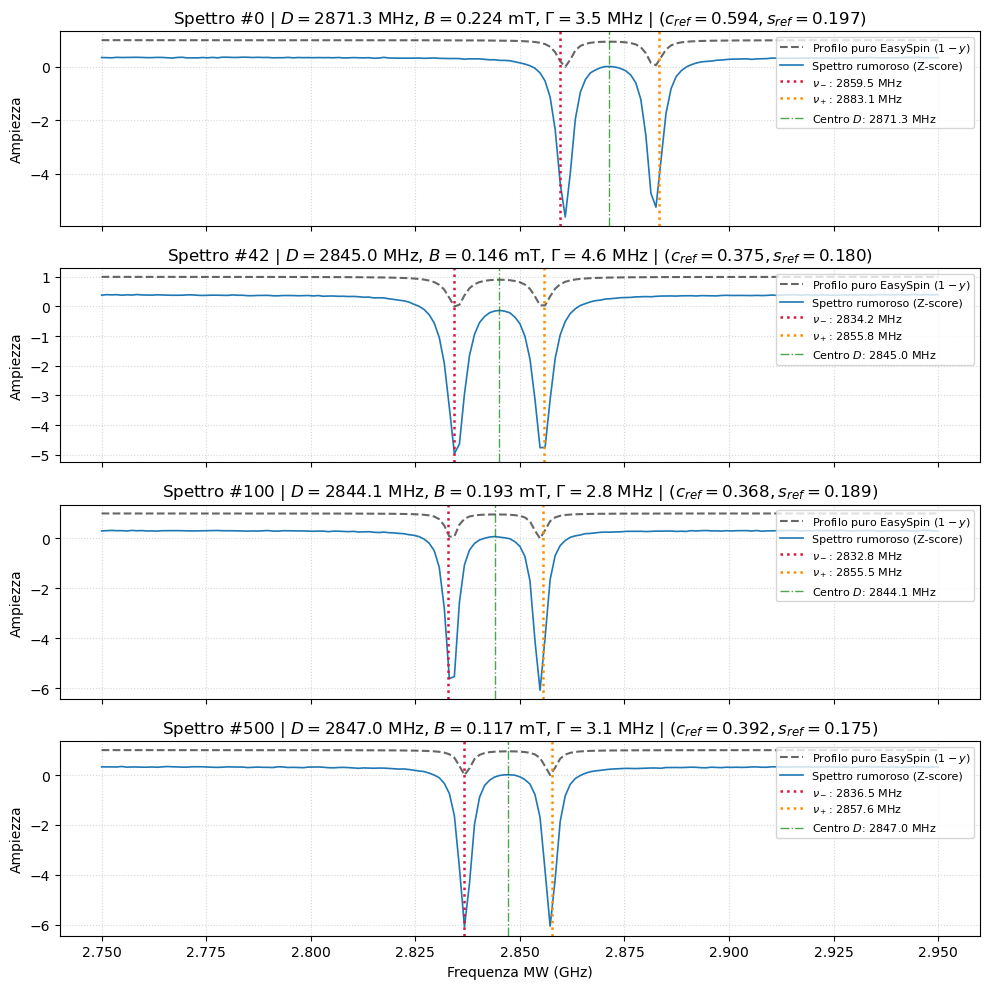

In [6]:
# Selezioniamo 4 indici di spettri dal dataset
sample_indices = [0, 42, 100, 500]

# Griglia di frequenze fisiche in GHz e MHz
f_ghz = mw_freqs  # array da 2.75 a 2.95 GHz (167 punti)
f_mhz = (
    f_ghz * 1e3 if f_ghz.max() < 10.0 else f_ghz
)  # assicuriamoci sia in MHz per i calcoli

fig, axes = plt.subplots(
    len(sample_indices), 1, figsize=(10, 10), sharex=True
)

for ax_idx, idx in enumerate(sample_indices):
    ax = axes[ax_idx]

    # Spettro puro di assorbimento calcolato da EasySpin (normalizzato al picco 1)
    y_raw = spectra_data[idx]

    # Parametri fisici estratti da MATLAB
    D_val = labels_D[idx]  # in MHz
    B_val = labels_B[idx]  # in mT
    lw_val = labels_lw[idx]  # in MHz
    c_ref = labels_c[idx]  # centro normalizzato campionato su 120 MHz
    s_ref = labels_s[idx]  # splitting normalizzato campionato su 120 MHz

    # Frequenze teoriche monoassiali del laboratorio:
    delta_half = np.sqrt(10.0**2 + (28.0 * B_val) ** 2)
    nu_minus = D_val - delta_half
    nu_plus = D_val + delta_half

    # Simulazione rapida del segnale sperimentale (contrasto 10% + e 1 milione di fotoni)
    # nella versione definitiva sono valori da estrarre casualmente come fa Yao
    contrast = 0.10
    signal_ideal = 1.0 - contrast * y_raw
    n_photons = 10e9
    expected_photons = n_photons * (signal_ideal / np.sum(signal_ideal))
    noisy_photons = np.random.poisson(expected_photons)
    noisy_norm = (noisy_photons - np.mean(noisy_photons)) / np.std(
        noisy_photons
    )

    # Plot 1: Spettro ideale EasySpin invertito (profilo liscio di PL)
    ax.plot(
        f_ghz,
        1*(1.0 - y_raw),
        color="black",
        lw=1.5,
        alpha=0.6,
        linestyle="--",
        label="Profilo puro EasySpin ($1 - y$)",
    )

    # Plot 2: Spettro Z-score rumoroso
    ax.plot(
        f_ghz,
        noisy_norm,
        color="#1f77b4",
        lw=1.2,
        label="Spettro rumoroso (Z-score)",
    )

    # Riferimenti fisici dei picchi monoassiali
    ax.axvline(
        nu_minus / 1e3,
        color="crimson",
        linestyle=":",
        lw=1.8,
        label=f"$\\nu_-$: {nu_minus:.1f} MHz",
    )
    ax.axvline(
        nu_plus / 1e3,
        color="darkorange",
        linestyle=":",
        lw=1.8,
        label=f"$\\nu_+$: {nu_plus:.1f} MHz",
    )
    ax.axvline(
        D_val / 1e3,
        color="green",
        linestyle="-.",
        lw=1.0,
        alpha=0.7,
        label=f"Centro $D$: {D_val:.1f} MHz",
    )

    ax.set_ylabel("Ampiezza")
    ax.set_title(
        f"Spettro #{idx} | $D={D_val:.1f}$ MHz, $B={B_val:.3f}$ mT, $\\Gamma={lw_val:.1f}$ MHz | $(c_{{ref}}={c_ref:.3f}, s_{{ref}}={s_ref:.3f})$"
    )
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Frequenza MW (GHz)")
plt.tight_layout()
plt.show()